# A) Offline build
Import data

In [1]:
import pandas as pd

cases = pd.read_csv("/content/cases_cleaned.csv")
actions = pd.read_csv("/content/actions_cleaned_v5.csv")


print(cases.shape, actions.shape)
cases.head(5)

(196, 21) (1603, 17)


,case_id,title,category,risk_level,setting,date,location,injury_category,severity,primary_classification,...,what_could_have_happened,root_causes,causal_factors,what_went_well,lessons,actions_raw,raw_block,country,setting_primary,setting_bucket
0,1,Minor Vapor Release During Instrument Tubing R...,Safety,Medium,Chemical processing unit – general operations ...,2019,Canada,No Injury,Potentially Significant,Health and Safety,...,● Vapor cloud accumulation in a low-ventilatio...,● Isolation plan assumed the transmitter’s sec...,● Time pressure to finish tasks before a sched...,● Technician immediately stopped work and re-s...,● Treat all small-bore tubing as pressure-reta...,1. Action: Add explicit vent-point check to al...,Title: Minor Vapor Release During Instrument T...,Canada,Chemical processing unit,Industrial Operations
1,2,Unexpected Pressure Release During Sampling Li...,Safety,Medium,Utilities area – process sampling station,2021,USA,No Injury,Potentially Significant,Health and Safety,...,● Accumulation of warm vapor leading to therma...,● Isolation plan did not consider trapped flui...,● Crews relied on verbal confirmation rather t...,"● Technician backed away immediately, demonstr...",● Always verify vent paths for all small-bore ...,1. Action: Add mandatory trapped-volume assess...,Title: Unexpected Pressure Release During Samp...,USA,Utilities area,Utilities & Infrastructure
2,3,Vapor Release During Transfer Hose Connection ...,Safety,Medium,Chemical unloading bay at a mid-scale processi...,2023,Canada,Medical Treatment,Potentially Significant,Health and Safety,...,● Inhalation of a higher concentration of vapo...,● Isolation procedure did not include a mandat...,● Time pressure due to several totes scheduled...,● Stop-work authority used immediately.\n● Ven...,● Always confirm venting and draining of lines...,1\nAction: Add a vent-verification step to all...,Title: Vapor Release During Transfer Hose Conn...,Canada,Chemical unloading bay at a mid,Industrial Operations
3,4,Inhalation Exposure During Acid Dilution Setup,Safety,Medium,Quality Control Laboratory – Wet Chemistry Area,2022,Canada,Medical Treatment,Potentially Significant,Health and Safety,...,● Higher-dose inhalation leading to respirator...,● Laboratory ventilation standards did not spe...,● Technician focused on glassware placement an...,● Technician recognized symptoms early and ste...,● Always fully lower fume-hood sash to the ope...,1. Action: Add explicit “operational sash heig...,Title: Inhalation Exposure During Acid Dilutio...,Canada,Quality Control Laboratory,Laboratories & Testing
4,5,Solvent Transfer Splash During Sample Prep,Safety,Medium,Analytical Laboratory – Organic Sample Prep Bench,2021,Canada,First Aid,Potentially Significant,Health and Safety,...,● Solvent spray could have contacted the techn...,● No standardized setup for solvent-transfer t...,● Bench clutter reduced maneuverability and cr...,● Technician reacted quickly and used immediat...,● Establish defined bench layouts and minimum ...,1. Action: Create a standard solvent-dispensin...,Title: Solvent Transfer Splash During Sample P...,Canada,Analytical Laboratory,Laboratories & Testing


In [2]:
# Build text_for_embedding if missing
if "text_for_embedding" not in cases.columns:
    text_cols = [
        "what_happened",
        "what_could_have_happened",
        "root_causes",
        "causal_factors",
        "what_went_well",
        "lessons",
        "actions_raw"
    ]

    # keep only cols that actually exist
    text_cols = [c for c in text_cols if c in cases.columns]

    def safe_str(x):
        return "" if pd.isna(x) else str(x).strip()

    cases["text_for_embedding"] = ""
    for c in text_cols:
        cases["text_for_embedding"] = cases["text_for_embedding"] + cases[c].apply(safe_str) + "\n"

    cases["text_for_embedding"] = cases["text_for_embedding"].str.replace(r"\s+", " ", regex=True).str.strip()

# Save back so Streamlit sees it
cases.to_csv("/content/cases_cleaned.csv", index=False)

print("✅ Saved /content/cases_cleaned.csv with text_for_embedding. Columns now:", len(cases.columns))
print("Has text_for_embedding:", "text_for_embedding" in cases.columns)

✅ Saved /content/cases_cleaned.csv with text_for_embedding. Columns now: 22
Has text_for_embedding: True


In [3]:
# install Install + init Vertex AI
!pip -q install --upgrade google-cloud-aiplatform vertexai


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.8/131.8 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.5/320.5 kB 34.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colabsqlviz 0.2.11 requires protobuf<7.0.0,>=6.31.1, but you have protobuf 5.29.6 which is incompatible.
google-adk 1.25.0 requires google-cloud-aiplatform[agent-engines]<2.0.0,>=1.132.0, but you have google-cloud-aiplatform 1.71.1 which is incompatible.


In [4]:
import vertexai
from vertexai.language_models import TextEmbeddingInput, TextEmbeddingModel

In [5]:
!gcloud auth application-default login


You are running on a Google Compute Engine virtual machine.
The service credentials associated with this virtual machine
will automatically be used by Application Default
Credentials, so it is not necessary to use this command.

If you decide to proceed anyway, your user credentials may be visible
to others with access to this virtual machine. Are you sure you want
to authenticate with your personal account?

Do you want to continue (Y/n)?  Y

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fapplicationdefaultauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=Hg1fbKQ70Muk968ExEgUdf4pvRN2nT&prompt=consent&token_

In [6]:
!gcloud config get-value project
PROJECT_ID = "smart-portfolio-485120-s6"
LOCATION = "us-central1"


smart-portfolio-485120-s6


In [7]:
!gcloud auth login



You are running on a Google Compute Engine virtual machine.
It is recommended that you use service accounts for authentication.

You can run:

  $ gcloud config set account `ACCOUNT`

to switch accounts if necessary.

Your credentials may be visible to others with access to this
virtual machine. Are you sure you want to authenticate with
your personal account?

Do you want to continue (Y/n)?  Y

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=32555940559.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fappengine.admin+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcompute+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Faccounts.

In [8]:
!gcloud config set project smart-portfolio-485120-s6

Project 'smart-portfolio-485120-s6' lacks an 'environment' tag. Please create or add a tag with key 'environment' and a value like 'Production', 'Development', 'Test', or 'Staging'. Add an 'environment' tag using `gcloud resource-manager tags bindings create`. See https://cloud.google.com/resource-manager/docs/creating-managing-projects#designate_project_environments_with_tags for details.
Updated property [core/project].


In [9]:
!gcloud services enable aiplatform.googleapis.com
!gcloud services enable generativelanguage.googleapis.com


In [10]:
# confirm ADC file exist
!ls -l /content/.config/application_default_credentials.json


-rw------- 1 root root 402 Mar 14 16:24 /content/.config/application_default_credentials.json


In [11]:
# force library to use ADC
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/.config/application_default_credentials.json"


In [12]:
import vertexai
from vertexai.language_models import TextEmbeddingInput, TextEmbeddingModel

PROJECT_ID = "smart-portfolio-485120-s6"
LOCATION = "us-central1"

vertexai.init(project=PROJECT_ID, location=LOCATION)

model = TextEmbeddingModel.from_pretrained("gemini-embedding-001")
emb = model.get_embeddings(
    [TextEmbeddingInput("test", "RETRIEVAL_QUERY")],
    output_dimensionality=768
)
print(len(emb[0].values))

768


### Embed all cases

In [13]:
import re
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [14]:
# General text cleaning utilities
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

EXTRA_STOPWORDS = {
    "causing","caused","cause","causes","leading","lead","led",
    "potential","risk","resulted","resulting","could","may","might",
    "due","including","also","would","within","nearby",
    "equipment"  # optional: remove if you think it's meaningful
}

CUSTOM_STOPWORDS = list(set(ENGLISH_STOP_WORDS) | EXTRA_STOPWORDS)

def clean_text_series(s: pd.Series) -> pd.Series:
    """
    Basic cleaning aligned with typical classroom NLP notebooks:
    - lower
    - remove non-letters
    - normalize whitespace
    """
    s = s.fillna("").astype(str).str.lower()
    s = s.str.replace(r"[^a-z\s]", " ", regex=True)
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

def word_count_series(s: pd.Series) -> pd.Series:
    s = s.fillna("").astype(str)
    return s.str.split().apply(len)

In [15]:
# Fit vectorizers per column + extract top terms
def top_terms_from_matrix(matrix, feature_names, top_n=20):
    """
    matrix: sparse doc-term matrix
    Returns top terms by total weight across all docs.
    """
    totals = np.asarray(matrix.sum(axis=0)).ravel()
    idx = totals.argsort()[::-1][:top_n]
    return pd.DataFrame({
        "term": feature_names[idx],
        "score": totals[idx]
    })

def build_count_features(text: pd.Series, min_df=3, ngram_range=(1,1), stop_words=CUSTOM_STOPWORDS):
    vec = CountVectorizer(min_df=min_df, ngram_range=ngram_range, stop_words=stop_words)
    X = vec.fit_transform(text)
    top_terms = top_terms_from_matrix(X, vec.get_feature_names_out(), top_n=30)
    return {"vectorizer": vec, "matrix": X, "top_terms": top_terms}

def build_tfidf_features(text: pd.Series, min_df=3, ngram_range=(1,1), stop_words=CUSTOM_STOPWORDS):
    vec = TfidfVectorizer(min_df=min_df, ngram_range=ngram_range, stop_words=stop_words)
    X = vec.fit_transform(text)
    top_terms = top_terms_from_matrix(X, vec.get_feature_names_out(), top_n=30)
    return {"vectorizer": vec, "matrix": X, "top_terms": top_terms}

In [16]:
# One master function for multiple columns
def text_eda_for_columns(
    df: pd.DataFrame,
    text_cols: list[str],
    min_df=3,
    ngram_range=(1,1),
    stop_words=CUSTOM_STOPWORDS,
    make_combined_col: bool = True,
    combined_col_name: str = "all_text_combined"
):
    """
    For each text column:
    - create cleaned version: f"{col}__clean"
    - create word count: f"{col}__wc"
    - fit CountVectorizer + TFIDF for that column
    Returns:
      df_out, artifacts
    where artifacts contains matrices/vectorizers/top_terms for each col.
    """
    df_out = df.copy()

    artifacts = {
        "columns": {},
        "params": {
            "min_df": min_df,
            "ngram_range": ngram_range,
            "stop_words": stop_words
        }
    }

    # Clean + counts
    for col in text_cols:
        clean_col = f"{col}__clean"
        wc_col = f"{col}__wc"

        df_out[clean_col] = clean_text_series(df_out[col])
        df_out[wc_col] = word_count_series(df_out[col])

        # Vectorizers
        count_pack = build_count_features(df_out[clean_col], min_df=min_df, ngram_range=ngram_range, stop_words=stop_words)
        tfidf_pack = build_tfidf_features(df_out[clean_col], min_df=min_df, ngram_range=ngram_range, stop_words=stop_words)

        artifacts["columns"][col] = {
            "clean_col": clean_col,
            "wc_col": wc_col,
            "count": count_pack,
            "tfidf": tfidf_pack
        }

    # Optional combined column (useful for embeddings)
    if make_combined_col:
        clean_cols = [artifacts["columns"][c]["clean_col"] for c in text_cols]
        df_out[combined_col_name] = df_out[clean_cols].agg(" ".join, axis=1).str.replace(r"\s+", " ", regex=True).str.strip()
        df_out[combined_col_name + "__wc"] = df_out[combined_col_name].str.split().apply(len)

        artifacts["combined"] = {
            "combined_col_name": combined_col_name,
            "source_clean_cols": clean_cols
        }

    return df_out, artifacts

In [17]:
# Use it on dataset
cases = pd.read_csv("cases_cleaned.csv")

text_cols = [
    "what_happened",
    "what_could_have_happened",
    "root_causes",
    "causal_factors",
    "what_went_well",
    "lessons",
    "actions_raw"
]

cases_out, artifacts = text_eda_for_columns(
    cases,
    text_cols=text_cols,
    min_df=3,
    ngram_range=(1,1),
    make_combined_col=True,
    combined_col_name="text_for_embedding"
)

# Example: see top TFIDF terms for one column
print(artifacts["columns"]["what_could_have_happened"]["tfidf"]["top_terms"].head(20))

           term     score
0       release  8.283077
1      pressure  7.184002
2      exposure  6.238175
3        injury  6.224926
4        damage  6.085159
5      movement  6.056540
6        impact  5.704128
7     sensitive  5.545242
8          loss  5.485919
9       process  5.403170
10  information  5.403022
11         data  5.355249
12     injuries  5.290180
13   escalation  5.234606
14       sudden  5.105774
15         line  4.891094
16         high  4.833865
17         area  4.664611
18        valve  4.579328
19        burns  4.570132


### Word2Vex

In [18]:
!pip install gensim
from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.5 MB/s eta 0:00:00


In [19]:
def train_word2vec(df: pd.DataFrame, clean_text_col: str, vector_size=50, window=5, min_count=5, sg=1, workers=4):
    docs = df[clean_text_col].fillna("").astype(str).str.split().tolist()
    model = Word2Vec(
        sentences=docs,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=sg,
        workers=workers
    )
    return model

w2v_model = train_word2vec(cases_out, "text_for_embedding")
w2v_model.wv.most_similar("pressure")

[('complete', 0.8430204391479492),
 ('under', 0.8007020950317383),
 ('pneumatic', 0.7920701503753662),
 ('workload', 0.7832804322242737),
 ('residual', 0.7827314138412476),
 ('reduced', 0.7760006189346313),
 ('volume', 0.7759271860122681),
 ('hydraulic', 0.7679483294487),
 ('outage', 0.7658402323722839),
 ('compressed', 0.7626124620437622)]

### Clustering

In [20]:
# combine all the text columns data
cases_out, artifacts_combined = text_eda_for_columns(
    cases_out,
    text_cols=["text_for_embedding"],
    min_df=3,
    ngram_range=(1,1),
    make_combined_col=False
)

In [21]:
# build the cluster matrix
pack = artifacts_combined["columns"]["text_for_embedding"]["tfidf"]

X = pack["matrix"]
terms = pack["vectorizer"].get_feature_names_out()

X.shape

(196, 2910)

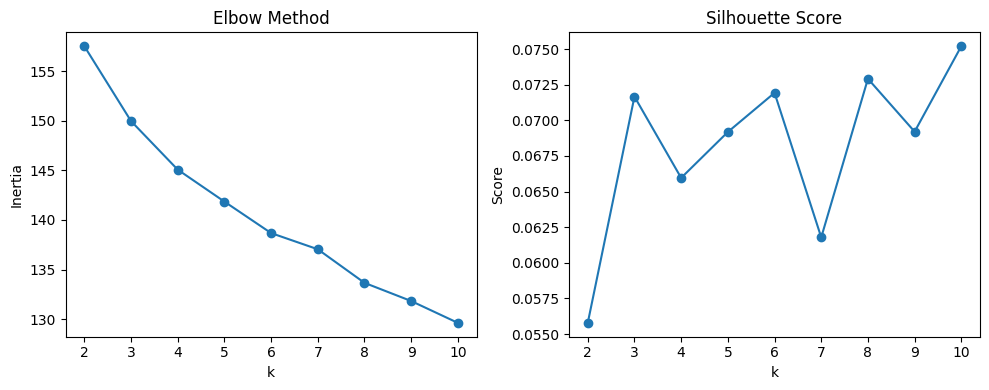

In [22]:
# Determine optimal number of clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)
inertia = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

# plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

In [23]:
k = 5 # optimal k

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cases_out["cluster"] = kmeans.fit_predict(X)

cases_out["cluster"].value_counts()

,count
cluster,
2,71
0,38
1,35
3,27
4,25


### Understand Clusters

Word2Vec-driven topic generation (unique topics)

In [24]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# ---------- helpers ----------
def w2v_mean_vec(model, word_list):
    vecs = [model.wv[w] for w in word_list if w in model.wv]
    if not vecs:
        return None
    return np.mean(vecs, axis=0)

def get_cluster_top_terms(kmeans, terms, n_terms=15):
    centers = kmeans.cluster_centers_
    out = {}
    for cid, center in enumerate(centers):
        idx = center.argsort()[::-1][:n_terms]
        out[cid] = [terms[i] for i in idx]
    return out

def build_theme_bank(model, theme_seeds, expand_topn=25, min_sim=0.60):
    """
    theme_seeds: dict(theme -> list of seed words)
    expands each seed via Word2Vec neighbors to create richer theme vocabulary.
    """
    bank = {}
    for theme, seeds in theme_seeds.items():
        words = set()
        for s in seeds:
            if s in model.wv:
                words.add(s)
                for w, sim in model.wv.most_similar(s, topn=expand_topn):
                    if sim >= min_sim:
                        words.add(w)
        words = sorted(words)
        v = w2v_mean_vec(model, words)
        bank[theme] = {"seeds": seeds, "words": words, "vector": v}
    return bank

def choose_best_theme(cluster_vec, theme_bank):
    sims = {}
    for theme, info in theme_bank.items():
        tv = info["vector"]
        if tv is None or cluster_vec is None:
            continue
        sims[theme] = float(cosine_similarity(cluster_vec.reshape(1,-1), tv.reshape(1,-1))[0][0])
    if not sims:
        return None, None
    best = max(sims, key=sims.get)
    return best, sims[best]

def make_signature_terms(cluster_terms, global_term_rank, n=3, ban=None):
    """
    Pick 'signature terms' that are:
    - in cluster_terms
    - not generic
    - relatively distinctive (prefer terms with lower global rank i.e. less common)
    """
    ban = ban or set()
    candidates = [t for t in cluster_terms if t not in ban]
    # sort by global rarity (higher rank value => rarer)
    candidates.sort(key=lambda t: global_term_rank.get(t, 0), reverse=True)
    return candidates[:n]

# ---------- main function ----------
def generate_cluster_topics_word2vec(
    cases_out, kmeans, terms, w2v_model,
    top_terms_per_cluster=18,
    signature_terms_n=3,
    min_sim=0.60
):
    # 1) get top terms from each cluster
    cluster_terms = get_cluster_top_terms(kmeans, terms, n_terms=top_terms_per_cluster)

    # 2) compute a global "rarity rank" for terms using centroid-weight sums (proxy for commonness)
    #    More common terms appear high in many centroids; rarer terms are better signatures.
    centers = kmeans.cluster_centers_
    commonness = centers.sum(axis=0)
    order = commonness.argsort()  # least common -> most common
    global_term_rank = {terms[i]: r for r, i in enumerate(order)}  # higher rank = more common? (we'll use reverse)
    # invert so higher means rarer
    maxr = max(global_term_rank.values())
    global_term_rank = {t: (maxr - r) for t, r in global_term_rank.items()}

    # 3) define theme seeds (tune later, but should already reduce duplicates)
    theme_seeds = {
        "Office / Confidentiality": ["hr", "employee", "office", "meeting", "confidential"],
        "AI / Automation": ["ai", "model", "sensor", "logic", "alarm"],
        "Isolation / LOTO": ["isolation", "lockout", "bleed", "valve", "permit"],
        "Stored Energy (Hydraulic/Pneumatic)": ["hydraulic", "pneumatic", "accumulator", "pressure", "residual"],
        "Access / Privilege Security": ["access", "privilege", "credential", "permission", "security"],
        "Operations / Equipment": ["operator", "pump", "equipment", "process", "control"],
    }
    theme_bank = build_theme_bank(w2v_model, theme_seeds, expand_topn=25, min_sim=min_sim)

    # 4) generate topics
    rows = []
    used_topics = set()

    GENERIC_BAN = {"verification","owner","action","timing","days","role","work"}  # tweak if needed

    for cid, kw in cluster_terms.items():
        # cluster semantic vector from top terms
        cluster_vec = w2v_mean_vec(w2v_model, kw)

        best_theme, sim = choose_best_theme(cluster_vec, theme_bank)
        if best_theme is None:
            best_theme, sim = "Other", np.nan

        # add signature terms to avoid duplicates
        sig = make_signature_terms(kw, global_term_rank, n=signature_terms_n, ban=GENERIC_BAN)
        sig_str = " / ".join(sig).title() if sig else ""

        # build topic
        topic = best_theme if sig_str == "" else f"{best_theme} — {sig_str}"

        # if still duplicate, append cluster id (last resort, should rarely happen)
        if topic in used_topics:
            topic = f"{topic} (C{cid})"
        used_topics.add(topic)

        rows.append({
            "cluster": cid,
            "topic": topic,
            "theme": best_theme,
            "theme_similarity": sim,
            "top_terms": ", ".join(kw),
        })

    topic_df = pd.DataFrame(rows).sort_values("cluster")
    return topic_df


# ---- RUN ----
topic_df = generate_cluster_topics_word2vec(
    cases_out=cases_out,
    kmeans=kmeans,
    terms=terms,
    w2v_model=w2v_model,
    top_terms_per_cluster=18,
    signature_terms_n=3,
    min_sim=0.60
)

topic_df

,cluster,topic,theme,theme_similarity,top_terms
0,0,Access / Privilege Security — Privacy / Home /...,Access / Privilege Security,0.941300,"hr, employee, verification, owner, action, tim..."
1,1,AI / Automation — Temperature / Recommendation...,AI / Automation,0.937102,"ai, model, role, verification, sensor, operato..."
2,2,Isolation / LOTO — Chemical / Permit / Area,Isolation / LOTO,0.865584,"verification, isolation, action, owner, timing..."
3,3,Isolation / LOTO — Air / Ptw / Bleed,Isolation / LOTO,0.915655,"hydraulic, energy, isolation, actuator, pneuma..."
4,4,Access / Privilege Security — Dosing / Corrido...,Access / Privilege Security,0.968942,"access, verification, security, action, owner,..."


In [25]:
rename_map = {
    0: "Information Privacy & Confidential Exposure Risk",
    1: "AI & Automation Control Reliability Risk",
    2: "Isolation & Permit Compliance Risk",
    3: "Stored Energy & Pressure Release Hazard",
    4: "Access Control & Privilege Misuse Risk"
}

topic_df["topic"] = topic_df["cluster"].map(rename_map)

topic_df

,cluster,topic,theme,theme_similarity,top_terms
0,0,Information Privacy & Confidential Exposure Risk,Access / Privilege Security,0.941300,"hr, employee, verification, owner, action, tim..."
1,1,AI & Automation Control Reliability Risk,AI / Automation,0.937102,"ai, model, role, verification, sensor, operato..."
2,2,Isolation & Permit Compliance Risk,Isolation / LOTO,0.865584,"verification, isolation, action, owner, timing..."
3,3,Stored Energy & Pressure Release Hazard,Isolation / LOTO,0.915655,"hydraulic, energy, isolation, actuator, pneuma..."
4,4,Access Control & Privilege Misuse Risk,Access / Privilege Security,0.968942,"access, verification, security, action, owner,..."


### Connect clusters to severity & context
Cluster vs Category

In [26]:
pd.crosstab(cases_out["cluster"], cases_out["category"])

category,Incident,Near Miss,Operational Efficiency,Quality,Reliability,Safety,Security
cluster,,,,,,,
0,15,3,0,0,0,1,19
1,32,0,0,2,1,0,0
2,23,21,1,2,0,22,2
3,0,24,0,0,0,3,0
4,1,9,0,0,0,1,14


Cluster vs Setting

In [27]:
pd.crosstab(cases_out["cluster"], cases_out["setting_bucket"])

setting_bucket,Construction & Temporary Work Zones,Corporate / Office / Administrative,Electrical & Power Systems,Industrial Operations,Laboratories & Testing,"Logistics, Access & Perimeter Areas",Maintenance & Mechanical,Operations Control & Digital Systems,Other / Review,Remote & Public Work Environments,Utilities & Infrastructure
cluster,,,,,,,,,,,
0,0,8,1,1,0,0,0,0,0,28,0
1,0,2,0,31,0,0,0,2,0,0,0
2,2,4,3,36,3,0,5,0,4,1,13
3,0,0,0,10,0,0,4,1,0,0,12
4,0,1,1,5,0,3,2,8,0,0,5


Cluster vs Risk level

In [28]:
pd.crosstab(cases_out["cluster"], cases_out["risk_level"])

risk_level,High,Low,Medium
cluster,,,
0,20,0,18
1,13,1,21
2,50,0,21
3,27,0,0
4,19,0,6


# B) Online query flow: Scenario/Cluster match → Similar cases

In [29]:
from sklearn.metrics.pairwise import cosine_similarity

def doc_vector(model, text):
    words = ("" if pd.isna(text) else str(text)).lower().split()
    vecs = [model.wv[w] for w in words if w in model.wv]
    if not vecs:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

# Precompute document vectors (do this once)
doc_vecs = np.vstack([doc_vector(w2v_model, t) for t in cases_out["text_for_embedding"]])

def most_similar_cases(query_text, top_k=5):
    qv = doc_vector(w2v_model, query_text).reshape(1, -1)
    sims = cosine_similarity(qv, doc_vecs).ravel()
    idx = sims.argsort()[::-1][:top_k]
    return cases_out.iloc[idx][["case_id", "title", "category", "setting_bucket"]].assign(similarity=sims[idx])

# Example
most_similar_cases("hydraulic pressure remained trapped during isolation; unexpected release", top_k=5)

,case_id,title,category,setting_bucket,similarity
188,189,Blocked Bleed‑Path Failure Led to Unexpected,Near Miss,Industrial Operations,0.849449
185,186,Hidden Hydraulic Accumulator Pressure,Near Miss,Industrial Operations,0.842684
32,33,Chemical Residue Release and Mechanical,Incident,Industrial Operations,0.835603
186,187,Accumulator Isolation Drift Resulted in,Near Miss,Utilities & Infrastructure,0.829431
183,184,Dual-Motion Actuator Misalignment Caused,Safety,Industrial Operations,0.827559


B1. Build Word2Vec doc vectors once (assets)

In [30]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

def doc_vector_w2v(w2v_model, text: str):
    words = ("" if pd.isna(text) else str(text)).lower().split()
    vecs = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    if not vecs:
        return np.zeros(w2v_model.vector_size, dtype="float32")
    v = np.mean(vecs, axis=0).astype("float32")
    v = v / (np.linalg.norm(v) + 1e-9)
    return v

def build_assets_word2vec(cases_df: pd.DataFrame, w2v_model, text_col="text_for_embedding", n_clusters=5, random_state=42):
    """
    Build assets once:
      - document vectors
      - kmeans for scenario routing
      - scenario_id for each case
    """
    texts = cases_df[text_col].fillna("").astype(str).tolist()
    doc_vecs = np.vstack([doc_vector_w2v(w2v_model, t) for t in texts])
    doc_vecs = doc_vecs / (np.linalg.norm(doc_vecs, axis=1, keepdims=True) + 1e-9)

    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    scenario_id = km.fit_predict(doc_vecs)

    cases_out = cases_df.copy()
    cases_out["scenario_id"] = scenario_id

    assets = {
        "w2v_model": w2v_model,
        "doc_vecs": doc_vecs,
        "kmeans": km,
        "text_col": text_col,
        "n_clusters": n_clusters
    }
    return assets, cases_out

 B2. Query-time retrieval using Word2Vec similarity

In [31]:
def assign_scenario_w2v(q_vec: np.ndarray, centroids: np.ndarray):
    sims = centroids @ q_vec
    sid = int(np.argmax(sims))
    conf = float(np.max(sims))
    return sid, conf

def retrieve_similar_cases_word2vec(query_text: str, cases_df: pd.DataFrame, assets: dict, topk=5, filter_by_scenario=True):
    w2v_model = assets["w2v_model"]
    doc_vecs = assets["doc_vecs"]
    km = assets["kmeans"]

    q_vec = doc_vector_w2v(w2v_model, query_text)
    centroids = km.cluster_centers_.astype("float32")
    centroids = centroids / (np.linalg.norm(centroids, axis=1, keepdims=True) + 1e-9)

    sid, conf = assign_scenario_w2v(q_vec, centroids)

    sims = cosine_similarity(q_vec.reshape(1, -1), doc_vecs).ravel()
    df = cases_df.copy()
    df["similarity"] = sims

    if filter_by_scenario and "scenario_id" in df.columns:
        df = df[df["scenario_id"] == sid]

    neighbors = df.sort_values("similarity", ascending=False).head(topk)
    return sid, conf, neighbors

B3. Recommend actions from neighbors

In [32]:
def recommend_actions_from_neighbors(neighbors_df: pd.DataFrame, actions_feat: pd.DataFrame, top_n=15):
    if neighbors_df.empty or "case_id" not in neighbors_df.columns or "case_id" not in actions_feat.columns:
        return {"top_actions": pd.DataFrame()}

    sub = actions_feat[actions_feat["case_id"].isin(neighbors_df["case_id"])].copy()

    keep_cols = [c for c in ["case_id","action_title","action_type","control_level","timing"] if c in sub.columns]
    top_actions = sub[keep_cols].head(top_n) if keep_cols else sub.head(top_n)

    return {"top_actions": top_actions}

B4. App-facing wrapper

In [33]:
def run_recommender_word2vec(query_text: str, topk_cases: int, cases: pd.DataFrame, actions_feat: pd.DataFrame, assets: dict):
    sid, conf, neighbors = retrieve_similar_cases_word2vec(
        query_text=query_text,
        cases_df=cases,
        assets=assets,
        topk=topk_cases,
        filter_by_scenario=True
    )

    rec = recommend_actions_from_neighbors(neighbors, actions_feat)

    show_cols = [c for c in ["case_id","title","category","severity","risk_level","setting_bucket","location","country","scenario_id","similarity"] if c in neighbors.columns]
    neighbors_df = neighbors[show_cols].copy() if show_cols else neighbors.copy()

    return sid, conf, neighbors_df, rec

Create simple web UI

In [34]:
pip -q install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 83.0 MB/s eta 0:00:00


### Create app demo

In [35]:
%%writefile /content/recommender.py
import re
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# Action type mapping (YOUR NEW RULES)
# ============================================================
ACTION_TYPE_RULES = [
    ("Audit/Verification/Assessment",
     r"\b("
     r"audit(s)?|auditing|"
     r"inspection(s)?|inspect(ing)?|"
     r"assessment(s)?|assess(ing)?|"
     r"review(s)?|review(ing)?|"
     r"verify|verification|validated|validation|"
     r"test(s)?|testing|"
     r"walkdown(s)?|walk[- ]down(s)?|field\s*walkdown(s)?|field\s*check(s)?|"
     r"spot\s*check(s)?|"
     r"sign[- ]off|approval|"
     r"confirm(ation)?|"
     r"accuracy|drift"
     r")\b"),
    ("Visual Management/Signage",
     r"\b("
     r"label(l)?(ing)?|"
     r"signage|sign(s)?|"
     r"tag(s)?|tagging|"
     r"marker(s)?|"
     r"high[- ]visibility|visibility|"
     r"color[- ]?coded?|lanyard(s)?|"
     r"qr[- ]?code(d)?|"
     r"plate(s)?"
     r")\b"),
    ("Procedure/Standard",
     r"\b("
     r"procedure(s)?|sop(s)?|standard(s)?|"
     r"checklist(s)?|permit(s)?|policy|"
     r"loto|lockout|tagout|"
     r"rule(s)?|guideline(s)?|"
     r"template(s)?|form(s)?|"
     r"protocol(s)?|"
     r"require(s|d)?|mandatory|"
     r"hierarchy|"
     r"documentation\s*gap(s)?|documentation\s*accuracy|"
     r"document\s*control|"
     r"single[- ]source[- ]of[- ]truth"
     r")\b"),
    ("Training/Drills",
     r"\b("
     r"training|refresher|toolbox|toolbox\s*talk|"
     r"drill(s)?|exercise(s)?|"
     r"awareness|quiz|"
     r"brief(ing)?|pre[- ]job\s*brief(ing)?|"
     r"campaign(s)?|coaching|"
     r"onboarding|orientation"
     r")\b"),
    ("Communication/Coordination",
     r"\b("
     r"handover|hand[- ]over|shift[- ]handover|"
     r"communication(s)?|"
     r"coordination|coordinate|"
     r"interface|alignment|"
     r"radio|"
     r"simops|"
     r"contractor[- ]operations|joint\s*contractor|"
     r"brief(ing)?"
     r")\b"),
    ("Equipment/Engineering Change",
     r"\b("
     r"install|add|modify|upgrade|retrofit|replace|refurbish|"
     r"implement|configure|"
     r"equipment|hardware|device(s)?|"
     r"valve(s)?|check\s*valve(s)?|actuator(s)?|"
     r"bleed\s*point(s)?|vent\s*plug(s)?|drain(s)?|"
     r"filter(s)?|screen(s)?|anemometer(s)?|"
     r"alarm(s)?|control\s*system(s)?|"
     r"p\&id(s)?|p&id(s)?|drawing(s)?|diagram(s)?|schematic(s)?|isometric(s)?|"
     r"layout(s)?|redesign|reposition|re[- ]design|"
     r"tracking\s*system|centralized\s*tracking|automated\s*alert|"
     r"digital\s*ptw|ptw\s*system|"
     r"single[- ]source[- ]of[- ]truth|synchronize(d)?|synchroni[sz]e(d)?|"
     r"consolidate|central(ized)?"
     r")\b"),
]

def _infer_action_type(text: str) -> str:
    s = ("" if pd.isna(text) else str(text)).lower()
    for label, pattern in ACTION_TYPE_RULES:
        if re.search(pattern, s, flags=re.I):
            return label
    return "Other/Unknown"


# ============================================================
# 0) Utilities
# ============================================================
def _tokenize(text: str):
    return ("" if pd.isna(text) else str(text)).lower().split()


def doc_vector_w2v(w2v_model, text: str):
    words = _tokenize(text)
    vecs = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    if not vecs:
        return np.zeros(w2v_model.vector_size, dtype="float32")
    v = np.mean(vecs, axis=0).astype("float32")
    v = v / (np.linalg.norm(v) + 1e-9)
    return v


def _pct_table(df: pd.DataFrame, col: str, top_n: int = 50):
    """
    Returns a pct mix table of a categorical column.
    top_n=50 so you don't lose categories too aggressively.
    """
    if df is None or col not in df.columns:
        return None
    s = df[col].dropna().astype(str).str.strip()
    if s.empty:
        return None
    vc = s.value_counts(normalize=True).mul(100).round(1).head(top_n)
    out = vc.reset_index()
    out.columns = [col, "pct"]
    return out


def get_case_details(cases_df: pd.DataFrame, case_id) -> dict:
    """
    Small helper for the app: returns the full case row as a dict (safe).
    """
    if cases_df is None or cases_df.empty or "case_id" not in cases_df.columns:
        return {}

    cid = pd.to_numeric(pd.Series([case_id]), errors="coerce").iloc[0]
    if pd.isna(cid):
        return {}

    df = cases_df.copy()
    df["case_id"] = pd.to_numeric(df["case_id"], errors="coerce")
    row = df[df["case_id"] == cid]
    if row.empty:
        return {}

    d = row.iloc[0].to_dict()
    for k, v in list(d.items()):
        if pd.isna(v):
            d[k] = ""
    return d


# ============================================================
# 1) Actions feature builder (schema adapter + mapping)
# ============================================================
def build_actions_feat(actions: pd.DataFrame) -> pd.DataFrame:
    df = actions.copy()

    # ensure presence for app usage
    for c in ["case_id", "action_title", "action_type", "control_level", "timing", "verification", "owner_role", "owner_bucket"]:
        if c not in df.columns:
            df[c] = None

    # clean key types
    df["case_id"] = pd.to_numeric(df["case_id"], errors="coerce")

    for c in ["action_title", "action_type", "control_level", "timing", "verification", "owner_role", "owner_bucket"]:
        df[c] = df[c].fillna("").astype(str).str.strip()

    # --- Apply YOUR action type logic when missing / unknown ---
    base_text = df["action_title"].fillna("").astype(str)

    # If your dataset has action_text, include it
    if "action_text" in df.columns:
        base_text = (df["action_title"].fillna("").astype(str) + " " + df["action_text"].fillna("").astype(str)).str.strip()

    mask = df["action_type"].isin(["", "Other", "Other/Unknown", "Unknown", "(Unknown)"])
    df.loc[mask, "action_type"] = base_text[mask].apply(_infer_action_type)

    return df


# ============================================================
# 2) Build assets ONCE (Word2Vec doc vectors + KMeans routing)
# ============================================================
def build_assets_word2vec(
    cases_df: pd.DataFrame,
    w2v_model,
    text_col: str = "text_for_embedding",
    n_clusters: int = 5,
    random_state: int = 42
):
    if text_col not in cases_df.columns:
        raise ValueError(f"text_col '{text_col}' not found in cases_df.columns")

    texts = cases_df[text_col].fillna("").astype(str).tolist()
    doc_vecs = np.vstack([doc_vector_w2v(w2v_model, t) for t in texts]).astype("float32")
    doc_vecs = doc_vecs / (np.linalg.norm(doc_vecs, axis=1, keepdims=True) + 1e-9)

    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    scenario_id = km.fit_predict(doc_vecs)

    cases_out = cases_df.copy()
    cases_out["scenario_id"] = scenario_id

    assets = {
        "w2v_model": w2v_model,
        "doc_vecs": doc_vecs,
        "kmeans": km,
        "text_col": text_col,
        "n_clusters": n_clusters
    }
    return assets, cases_out


# ============================================================
# 3) Retrieval
# ============================================================
def assign_scenario_w2v(q_vec: np.ndarray, centroids: np.ndarray):
    sims = centroids @ q_vec
    sid = int(np.argmax(sims))
    conf = float(np.max(sims))
    return sid, conf


def _apply_optional_filters(df: pd.DataFrame, filters: dict | None):
    if not filters:
        return df
    out = df
    for col, val in filters.items():
        if val is None:
            continue
        sval = str(val).strip()
        if sval == "" or sval == "(Unknown)":
            continue
        if col not in out.columns:
            continue
        out = out[out[col].astype(str) == sval]
    return out


def retrieve_similar_cases_word2vec(
    query_text: str,
    cases_df: pd.DataFrame,
    assets: dict,
    topk: int = 5,
    filters: dict | None = None,
    filter_by_scenario: bool = True
):
    w2v_model = assets["w2v_model"]
    doc_vecs = assets["doc_vecs"]
    km = assets["kmeans"]

    q_vec = doc_vector_w2v(w2v_model, query_text)
    centroids = km.cluster_centers_.astype("float32")
    centroids = centroids / (np.linalg.norm(centroids, axis=1, keepdims=True) + 1e-9)

    sid, conf = assign_scenario_w2v(q_vec, centroids)

    sims = cosine_similarity(q_vec.reshape(1, -1), doc_vecs).ravel()
    df = cases_df.copy()
    df["similarity"] = sims

    if filter_by_scenario and "scenario_id" in df.columns:
        df = df[df["scenario_id"] == sid]

    df_f = _apply_optional_filters(df, filters)
    if len(df_f) > 0:
        df = df_f

    neighbors = df.sort_values("similarity", ascending=False).head(topk).reset_index(drop=True)
    return sid, conf, neighbors


# ============================================================
# 4) Recommend actions + insights
# ============================================================
def recommend_actions_from_neighbors(
    neighbors_df: pd.DataFrame,
    actions_feat: pd.DataFrame,
    top_n: int = 80
):
    if neighbors_df.empty or "case_id" not in neighbors_df.columns or "case_id" not in actions_feat.columns:
        return {"top_actions": pd.DataFrame()}

    ids = pd.to_numeric(neighbors_df["case_id"], errors="coerce")
    sub = actions_feat[actions_feat["case_id"].isin(ids)].copy()
    if sub.empty:
        return {"top_actions": pd.DataFrame()}

    keep_cols = [c for c in ["case_id", "action_title", "action_type", "control_level", "timing", "verification", "owner_bucket", "owner_role"] if c in sub.columns]
    top_actions = sub[keep_cols].head(top_n) if keep_cols else sub.head(top_n)
    return {"top_actions": top_actions}


def build_action_insights(neighbors_df: pd.DataFrame, actions_feat: pd.DataFrame):
    if neighbors_df.empty or "case_id" not in neighbors_df.columns:
        return {}

    ids = pd.to_numeric(neighbors_df["case_id"], errors="coerce")
    sub = actions_feat[actions_feat["case_id"].isin(ids)].copy()
    if sub.empty:
        return {}

    roles_col = None
    for c in ["owner_bucket", "owner_role"]:
        if c in sub.columns:
            roles_col = c
            break

    return {
        "n_actions": int(len(sub)),
        "action_type_mix": _pct_table(sub, "action_type", top_n=50),
        "control_level_mix": _pct_table(sub, "control_level", top_n=50),
        "timing_mix": _pct_table(sub, "timing", top_n=50),
        "top_roles": _pct_table(sub, roles_col, top_n=50) if roles_col else None,
    }


# ============================================================
# 5) App-facing wrapper
# ============================================================
def run_recommender_word2vec(
    query_text: str,
    topk_cases: int,
    cases: pd.DataFrame,
    actions_feat: pd.DataFrame,
    assets: dict,
    filters: dict | None = None
):
    sid, conf, neighbors = retrieve_similar_cases_word2vec(
        query_text=query_text,
        cases_df=cases,
        assets=assets,
        topk=topk_cases,
        filters=filters,
        filter_by_scenario=True
    )

    rec = recommend_actions_from_neighbors(neighbors, actions_feat, top_n=200)
    rec["action_insights"] = build_action_insights(neighbors, actions_feat)
    rec["confidence"] = conf

    show_cols = [c for c in [
        "case_id","title","category","severity","risk_level",
        "setting_bucket","setting","location","country",
        "scenario_id","similarity","date","date_parsed","year"
    ] if c in neighbors.columns]
    neighbors_df = neighbors[show_cols].copy() if show_cols else neighbors.copy()

    return sid, conf, neighbors_df, rec

Writing /content/recommender.py


In [36]:
%%writefile /content/app.py
import os
import streamlit as st
import pandas as pd
import altair as alt
import numpy as np
from gensim.models import Word2Vec

from recommender import (
    build_actions_feat,
    build_assets_word2vec,
    run_recommender_word2vec,
    get_case_details
)

st.set_page_config(page_title="Safety Assistant", layout="wide")

# ============================================================
# Scenario names + descriptions
# ============================================================
SCENARIO_INFO = {
    0: {
        "name": "Information Privacy & Confidential Exposure Risk",
        "desc": "Sensitive information or access paths unintentionally exposed (documents, sharing, admin/office contexts)."
    },
    1: {
        "name": "AI & Automation Control Reliability Risk",
        "desc": "Automation/sensors/models behaving unexpectedly; reliability of digital controls and decision logic."
    },
    2: {
        "name": "Isolation & Permit Compliance Risk",
        "desc": "Lockout/isolation/permit-to-work gaps; missing checks leading to unsafe work execution."
    },
    3: {
        "name": "Stored Energy & Pressure Release Hazard",
        "desc": "Residual hydraulic/pneumatic/pressure energy not fully relieved; unexpected release during intervention."
    },
    4: {
        "name": "Access Control & Privilege Misuse Risk",
        "desc": "Unauthorized access or privilege misuse (physical/digital); weak controls around who can do what."
    },
}

# ============================================================
# Action Type Descriptions (updated to match your NEW ACTION_TYPE_RULES order)
# ============================================================
ACTION_TYPE_DESC = {
    "Audit/Verification/Assessment": (
        "Checks that confirm controls are working: audits, inspections, walkdowns/field checks, reviews, "
        "testing/validation, sign-off/approvals, and confirmation steps (including drift/accuracy checks)."
    ),
    "Visual Management/Signage": (
        "Visual cues that reduce confusion and improve visibility: labels, signage, tags, markers, "
        "high-visibility indicators, color-coding, QR codes, plates/markers."
    ),
    "Procedure/Standard": (
        "Rules and standard work that guide how work should be done: procedures/SOPs, checklists, permits, "
        "policies, LOTO/lockout-tagout, templates/forms, protocols/requirements, and documentation control."
    ),
    "Training/Drills": (
        "Capability-building activities: training/refreshers, toolbox talks, drills/exercises, briefings "
        "(including pre-job), campaigns, coaching, onboarding/orientation."
    ),
    "Communication/Coordination": (
        "Coordination steps to align teams and avoid interface gaps: handovers (incl. shift handover), "
        "communications, coordination, alignment/interface management, radio comms, SIMOPS, contractor-ops interfaces."
    ),
    "Equipment/Engineering Change": (
        "Physical or system/tool changes: install/add/modify/upgrade/retrofit/replace equipment; "
        "valves/actuators/bleed points/vents/drains/filters/screens; alarms/control systems; "
        "drawings/P&IDs/diagrams; layout redesign; and tracking/system changes (e.g., centralized tracking, automated alerts, digital PTW)."
    ),
    "Other/Unknown": "Doesn’t clearly match a category yet (needs mapping/data cleanup).",
}

# ============================================================
# Owner bucket descriptions
# ============================================================
OWNER_DESC = {
    "IT/Digital": "Systems, apps, platforms, IAM/access management, cybersecurity/OT security, digital tools, data/analytics/AI roles.",
    "HSE": "Safety, risk, compliance, assurance, audits, emergency/incident response, and related site security roles.",
    "Engineering/Reliability": "Engineering & integrity: instrumentation/automation/electrical/commissioning, MOC, reliability, process safety, technical roles.",
    "Maintenance": "Maintenance execution/planning: mechanics, planners, CMMS/work orders, crafts/workshop/scaffolding-related maintenance work.",
    "Operations": "Operations execution & control: shifts, control room, PTW/permit issuer/coordinator, SIMOPS, performing/area authorities.",
    "Facilities/Field": "Facilities/field/workplace services: office services, reception, warehouse/logistics/stores, procurement/purchasing, site support.",
    "Contractor Mgmt": "Contractor/vendor/third-party oversight, onboarding, supervision, and performance management.",
    "HR/Learning": "People/HR: onboarding, learning, training programs, HRIS, people & culture.",
    "Management": "Leadership/coordination: supervisors/leads/managers/directors, heads/coordinators, corporate communications.",
    "": "Owner bucket not captured in this dataset.",
}

# ============================================================
# Control bucket mapping + descriptions
# ============================================================
CONTROL_BUCKET_DESC = {
    "Engineering Control": "Physical/engineered change that reduces hazard at the source (most robust).",
    "Administrative Control": "Rules/process/training/verification—effective but relies on compliance.",
    "Hybrid": "Visual cues supporting standards and behavior (between engineering and admin).",
    "Other/Unknown": "Not enough info to classify; needs review.",
}
ADMIN_TYPES = {
    "Procedure/Standard",
    "Training/Drills",
    "Communication/Coordination",
    "Audit/Verification/Assessment",
}
ENG_TYPES = {"Equipment/Engineering Change"}
HYB_TYPES = {"Visual Management/Signage"}

TIMING_ORDER = ["Immediate", "<30 days", "30-90 days", ">90 days", "Other/Unknown"]

def normalize_timing(t: str) -> str:
    s = ("" if pd.isna(t) else str(t)).strip().lower()
    if s in ["immediate", "now", "0", "0 days", "0 day"]:
        return "Immediate"
    if "<30" in s or "within 30" in s or ("30" in s and "day" in s and "<" in s):
        return "<30 days"
    if "30-90" in s or "30 – 90" in s or "30 to 90" in s:
        return "30-90 days"
    if ">90" in s or "90+" in s or "over 90" in s or "more than 90" in s:
        return ">90 days"
    if s == "":
        return "Other/Unknown"
    return "Other/Unknown"

def control_bucket_from_action_type(action_type: str) -> str:
    at = ("" if pd.isna(action_type) else str(action_type)).strip()
    if at in ENG_TYPES:
        return "Engineering Control"
    if at in ADMIN_TYPES:
        return "Administrative Control"
    if at in HYB_TYPES:
        return "Hybrid"
    return "Other/Unknown"

# ============================================================
# Styling
# ============================================================
st.markdown("""
<style>
.small-help { font-size: 13px; opacity: 0.75; }
.subtle { font-size: 13px; opacity: 0.70; margin-top: 6px; }
.green-chip {
  display:inline-block;
  padding:4px 10px;
  border-radius:999px;
  background: rgba(34,197,94,0.12);
  border: 1px solid rgba(34,197,94,0.35);
  font-size: 12px;
  font-weight: 600;
}
.soft-card {
  border:1px solid rgba(0,0,0,0.10);
  border-radius:14px;
  padding:14px 16px;
  background: rgba(255,255,255,0.7);
}
.alert-red {
  border-radius:14px;
  padding:12px 14px;
  border: 1px solid rgba(239,68,68,0.35);
  background: rgba(239,68,68,0.10);
}
.alert-yellow {
  border-radius:14px;
  padding:12px 14px;
  border: 1px solid rgba(234,179,8,0.40);
  background: rgba(234,179,8,0.12);
}
.alert-green {
  border-radius:14px;
  padding:12px 14px;
  border: 1px solid rgba(34,197,94,0.35);
  background: rgba(34,197,94,0.10);
}
.kpi-note { margin-top: 6px; opacity: 0.88; }
.section-title {
  font-size: 18px;
  font-weight: 800;
  margin-top: 4px;
  margin-bottom: 8px;
}
.action-box {
  border: 1px solid rgba(0,0,0,0.10);
  border-radius: 12px;
  padding: 10px 12px;
  background: rgba(255,255,255,0.85);
  margin-bottom: 10px;
}
.mini-muted { font-size: 12px; opacity: 0.70; margin-top: 4px; }
</style>
""", unsafe_allow_html=True)

# ============================================================
# Title
# ============================================================
st.title("🧑‍🔧 Safety helper — tell me what happened")
st.caption("I’ll pull similar past cases and suggested actions. Add optional context filters if you know them.")

# ============================================================
# Helpers
# ============================================================
def pct_from_0_100(x) -> str:
    try:
        v = float(x)
        return f"{v:.1f}%"
    except Exception:
        return "—"

def pct_0_1(x) -> str:
    try:
        v = float(x)
        return f"{v*100:.0f}%"
    except Exception:
        return "—"

def wrap_card(title: str, value_html: str, chip: str | None = None, subtitle: str | None = None):
    chip_html = f'<span class="green-chip">{chip}</span>' if chip else ""
    subtitle_html = f'<div class="subtle">{subtitle}</div>' if subtitle else ""
    st.markdown(
        f"""
        <div class="soft-card">
          <div style="display:flex;justify-content:space-between;align-items:center;gap:12px;">
            <div style="font-size:13px;opacity:0.75;">{title}</div>
            <div>{chip_html}</div>
          </div>
          <div style="font-size:18px;font-weight:800;line-height:1.25;margin-top:6px;word-break:break-word;">
            {value_html}
          </div>
          {subtitle_html}
        </div>
        """,
        unsafe_allow_html=True
    )

def hbar_breakdown(df: pd.DataFrame, label_col: str, value_col: str, gradient: bool = False, height_cap: int = 360):
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        st.info("No data available.")
        return

    d = df.copy()
    d[label_col] = d[label_col].astype(str)
    d[value_col] = pd.to_numeric(d[value_col], errors="coerce").fillna(0.0)
    d = d.sort_values(value_col, ascending=False)

    y = alt.Y(
        f"{label_col}:N",
        sort="-x",
        axis=alt.Axis(title=None, labelAngle=0, labelLimit=2000, labelPadding=10)
    )
    x = alt.X(f"{value_col}:Q", axis=alt.Axis(title=None))

    color_enc = (
        alt.Color(value_col, legend=None, scale=alt.Scale(scheme="blues"))
        if gradient else alt.value("#2D6CDF")
    )

    chart = (
        alt.Chart(d)
        .mark_bar()
        .encode(
            y=y,
            x=x,
            color=color_enc,
            tooltip=[label_col, alt.Tooltip(value_col, format=".1f")]
        )
        .properties(height=min(height_cap, 28 * max(4, len(d))))
    )
    st.altair_chart(chart, use_container_width=True)

def risk_level_pattern(neighbors_df: pd.DataFrame):
    if neighbors_df is None or neighbors_df.empty or "risk_level" not in neighbors_df.columns:
        st.info("No risk-level info available from similar cases.")
        return

    s = neighbors_df["risk_level"].fillna("").astype(str).str.strip().str.lower()

    def norm(v):
        if "high" in v: return "High"
        if "med" in v:  return "Medium"
        if "low" in v:  return "Low"
        return "Other"

    s2 = s.map(norm)
    total = len(s2)
    high = (s2 == "High").sum()
    med  = (s2 == "Medium").sum()
    low  = (s2 == "Low").sum()

    ph = 100 * high / total if total else 0
    pm = 100 * med / total if total else 0
    pl = 100 * low / total if total else 0

    mx = max(ph, pm, pl)
    if mx == ph:
        alert_cls = "alert-red";    alert_txt = "High risk is most common among similar past cases."
    elif mx == pm:
        alert_cls = "alert-yellow"; alert_txt = "Medium risk is most common among similar past cases."
    else:
        alert_cls = "alert-green";  alert_txt = "Low risk is most common among similar past cases."

    st.markdown(f'<div class="{alert_cls}"><div>Risk-level pattern (from similar cases)</div><div class="small-help">{alert_txt}</div></div>', unsafe_allow_html=True)
    c1, c2, c3 = st.columns(3)
    with c1: wrap_card("High", f"{ph:.1f}%", chip="🔥")
    with c2: wrap_card("Medium", f"{pm:.1f}%", chip="⚠️")
    with c3: wrap_card("Low", f"{pl:.1f}%", chip="✅")

def safe_txt(x) -> str:
    if x is None:
        return ""
    try:
        if isinstance(x, float) and np.isnan(x):
            return ""
    except Exception:
        pass
    return str(x).strip()

# ============================================================
# Load data
# ============================================================
@st.cache_data
def load_data():
    base = os.path.dirname(__file__)
    cases = pd.read_csv(os.path.join(base, "cases_cleaned.csv"))
    actions = pd.read_csv(os.path.join(base, "actions_cleaned_v5.csv"))
    return cases, actions

cases, actions = load_data()
actions_feat = build_actions_feat(actions)

if "text_for_embedding" not in cases.columns:
    st.error("cases_cleaned.csv must include a 'text_for_embedding' column.")
    st.stop()

# ============================================================
# Build Word2Vec + assets
# ============================================================
@st.cache_resource
def train_w2v_and_assets(cases_df: pd.DataFrame, text_col: str = "text_for_embedding", n_clusters: int = 5):
    sentences = cases_df[text_col].fillna("").astype(str).apply(lambda x: str(x).lower().split()).tolist()
    w2v_model = Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=5,
        min_count=2,
        sg=1,
        workers=4
    )
    assets, cases_out = build_assets_word2vec(
        cases_df=cases_df,
        w2v_model=w2v_model,
        text_col=text_col,
        n_clusters=n_clusters,
        random_state=42
    )
    return assets, cases_out

assets, cases_with_scenario = train_w2v_and_assets(cases, text_col="text_for_embedding", n_clusters=5)

# ============================================================
# Optional structured filters
# ============================================================
with st.expander("Optional details (fill what you know)", expanded=False):
    def opt_select(label, col_name):
        if col_name not in cases.columns:
            return None
        vals = sorted([v for v in cases[col_name].dropna().astype(str).unique().tolist() if v.strip() != ""])
        return st.selectbox(label, options=["(Unknown)"] + vals, index=0)

    sel_risk    = opt_select("Risk level", "risk_level")
    sel_sev     = opt_select("Severity / Injury level", "severity")
    sel_setting = opt_select("Setting", "setting_bucket" if "setting_bucket" in cases.columns else "setting")
    sel_country = opt_select("Country", "country")
    sel_cat     = opt_select("Category", "category")

    filters = {
        "risk_level": None if sel_risk == "(Unknown)" else sel_risk,
        "severity": None if sel_sev == "(Unknown)" else sel_sev,
        "setting_bucket": None,
        "setting": None,
        "country": None if sel_country == "(Unknown)" else sel_country,
        "category": None if sel_cat == "(Unknown)" else sel_cat,
    }
    if "setting_bucket" in cases.columns:
        filters["setting_bucket"] = None if sel_setting == "(Unknown)" else sel_setting
    elif "setting" in cases.columns:
        filters["setting"] = None if sel_setting == "(Unknown)" else sel_setting

# ============================================================
# Query UI (persist inputs so reruns don't clear)
# ============================================================
colQ1, colQ2 = st.columns(2)
with colQ1:
    q_happened = st.text_area("What happened?", height=140, key="q_happened")
with colQ2:
    q_could = st.text_area("What could have happened? (optional)", height=140, key="q_could")

extra_notes = st.text_area("Any extra context? (optional)", height=80, key="extra_notes")
topk_cases = st.slider("How many similar cases do you want?", 3, 20, 7, key="topk_cases")

# ============================================================
# Run (persist results so selecting a case doesn't wipe the screen)
# ============================================================
if st.button("Search"):
    if not (q_happened.strip() or q_could.strip() or extra_notes.strip()):
        st.warning("Please enter at least one description field.")
    else:
        parts = []
        if q_happened.strip(): parts.append("What happened:\n" + q_happened.strip())
        if q_could.strip():    parts.append("What could have happened:\n" + q_could.strip())
        if extra_notes.strip():parts.append("Notes:\n" + extra_notes.strip())

        hint_parts = []
        for k, v in filters.items():
            if v:
                hint_parts.append(f"{k.replace('_',' ')}: {v}")

        query_aug = "\n\n".join(parts)
        if hint_parts:
            query_aug += "\n\nContext: " + " | ".join(hint_parts)

        sid, conf, neighbors_df, rec = run_recommender_word2vec(
            query_text=query_aug,
            topk_cases=topk_cases,
            cases=cases_with_scenario,
            actions_feat=actions_feat,
            assets=assets,
            filters=filters
        )

        # Persist results for reruns (dropdown clicks, expanders, etc.)
        st.session_state["neighbors_df"] = neighbors_df
        st.session_state["rec"] = rec
        st.session_state["sid"] = sid
        st.session_state["conf"] = conf
        st.session_state["filters_used"] = filters

        # Set default selected case (first result)
        try:
            if neighbors_df is not None and not neighbors_df.empty and "case_id" in neighbors_df.columns:
                st.session_state["selected_case_id"] = int(pd.to_numeric(neighbors_df["case_id"], errors="coerce").dropna().iloc[0])
        except Exception:
            pass

# ============================================================
# Render results from session_state (so UI doesn't reset on widget changes)
# ============================================================
if "neighbors_df" in st.session_state and isinstance(st.session_state["neighbors_df"], pd.DataFrame):
    neighbors_df = st.session_state["neighbors_df"]
    rec = st.session_state.get("rec", {})
    sid = st.session_state.get("sid", 0)
    conf = st.session_state.get("conf", 0.0)

    # 1) Risk-level pattern
    risk_level_pattern(neighbors_df)
    st.divider()

    # 2) Top cards (updated wording)
    scen = SCENARIO_INFO.get(int(sid), {"name": f"Scenario #{sid}", "desc": ""})
    scen_name, scen_desc = scen["name"], scen["desc"]

    c1, c2, c3 = st.columns([2.2, 1.8, 1.0])
    with c1:
        value_html = f'<span title="{scen_desc}">Scenario #{sid}: {scen_name}</span>'
        wrap_card("Most similar scenario", value_html, chip="🎯", subtitle=scen_desc)
    with c2:
        wrap_card(
            "How we matched",
            "We find past cases with similar descriptions and context, then return the closest matches.",
            chip="🔎",
            subtitle=None
        )
    with c3:
        wrap_card(
            "Similarity strength",
            pct_0_1(conf),
            chip="✅",
            subtitle="A higher score means the match is closer."
        )

    st.divider()

    # 3) Action insights
    st.subheader("💡 Action insights")
    with st.popover("ℹ️ More information"):
        st.write("These summaries are calculated from actions linked to the similar cases shown below.")

    insights = rec.get("action_insights", {}) if isinstance(rec, dict) else {}
    at_df = insights.get("action_type_mix")
    tm_df = insights.get("timing_mix")
    roles_df = insights.get("top_roles")

    # --- Place action types (left) and timing mix (right) in parallel ---
    left, right = st.columns(2)

    # ---------- LEFT: Top action types ----------
    with left:
        st.markdown('<div class="section-title">🛠️ <b>Top action types</b></div>', unsafe_allow_html=True)

        if isinstance(at_df, pd.DataFrame) and not at_df.empty:
            top3 = at_df.sort_values("pct", ascending=False).head(3)
            kcols = st.columns(3)
            for i, (_, r) in enumerate(top3.iterrows()):
                atype = (str(r.get("action_type", "")) or "").strip() or "Other/Unknown"
                with kcols[i]:
                    st.metric(atype, pct_from_0_100(r["pct"]))
                    with st.popover("ℹ️ More information"):
                        st.write(ACTION_TYPE_DESC.get(atype, ACTION_TYPE_DESC["Other/Unknown"]))

            # Align row under the cards for breakdown button
            st.markdown('<div class="mini-muted"> </div>', unsafe_allow_html=True)
            with st.popover("View full breakdown"):
                hbar_breakdown(at_df, "action_type", "pct", gradient=False)
        else:
            st.info("No action-type data available.")

    # ---------- RIGHT: Timing mix ----------
    with right:
        st.markdown('<div class="section-title">⏱️ <b>Timing mix</b></div>', unsafe_allow_html=True)

        if isinstance(tm_df, pd.DataFrame) and not tm_df.empty:
            d = tm_df.copy()
            d["timing_norm"] = d["timing"].apply(normalize_timing)
            d = d.groupby("timing_norm", as_index=False)["pct"].sum()
            d["order"] = d["timing_norm"].apply(lambda x: TIMING_ORDER.index(x) if x in TIMING_ORDER else 999)
            d = d.sort_values("order").drop(columns=["order"])

            bins = ["Immediate", "<30 days", "30-90 days", ">90 days"]
            tcols = st.columns(4)
            for i, b in enumerate(bins):
                with tcols[i]:
                    val = float(d.loc[d["timing_norm"] == b, "pct"].sum()) if b in d["timing_norm"].values else 0.0
                    st.metric(b, f"{val:.1f}%")

            # Align breakdown button under the timing metrics, similar to action types
            st.markdown('<div class="mini-muted"> </div>', unsafe_allow_html=True)
            with st.popover("View full breakdown"):
                hbar_breakdown(d.rename(columns={"timing_norm": "timing"}), "timing", "pct", gradient=True)
        else:
            st.info("No timing data available.")

    st.markdown("")

    # ---------- Owners (below, with icon + bold + bigger font) ----------
    st.markdown('<div class="section-title">👥 <b>Most common action owners</b></div>', unsafe_allow_html=True)
    with st.popover("ℹ️ More information"):
        for k, v in OWNER_DESC.items():
            if k.strip():
                st.write(f"{k} — {v}")

    if isinstance(roles_df, pd.DataFrame) and not roles_df.empty:
        role_col = roles_df.columns[0]
        top3 = roles_df.sort_values("pct", ascending=False).head(3)
        ocols = st.columns(3)
        for i, (_, r) in enumerate(top3.iterrows()):
            owner = str(r.get(role_col, "")).strip()
            owner_disp = owner if owner else "Other/Unknown"
            with ocols[i]:
                st.metric(owner_disp, pct_from_0_100(r["pct"]))
                with st.popover("ℹ️ More information"):
                    st.write(OWNER_DESC.get(owner, "Owner bucket not recognized / needs mapping cleanup."))

        with st.popover("View full breakdown"):
            hbar_breakdown(roles_df, role_col, "pct", gradient=False)
    else:
        st.info("Owner fields not found in this actions file (that’s OK).")

    st.divider()

    # 4) Top Similar Cases (remove location)
    st.subheader("Top Similar Cases")
    show_df = neighbors_df.copy()

    if "similarity" in show_df.columns:
        show_df["similarity"] = pd.to_numeric(show_df["similarity"], errors="coerce")
        show_df["similarity (%)"] = (show_df["similarity"] * 100).round(1)
        show_df = show_df.drop(columns=["similarity"])

    if "location" in show_df.columns:
        show_df = show_df.drop(columns=["location"])

    preferred_order = [
        "case_id", "title", "category", "severity", "risk_level",
        "setting_bucket", "setting", "country",
        "scenario_id", "similarity (%)"
    ]
    cols = [c for c in preferred_order if c in show_df.columns] + [c for c in show_df.columns if c not in preferred_order]
    show_df = show_df[cols]
    st.dataframe(show_df, use_container_width=True, hide_index=True)

    st.divider()

    # NEW: Selected case details (dropdown) — persists without wiping results
    if show_df is not None and not show_df.empty and "case_id" in show_df.columns:
        st.markdown('<div class="section-title">📄 <b>Selected case details</b></div>', unsafe_allow_html=True)

        def _label_row(r):
            cid = r.get("case_id", "")
            ttl = str(r.get("title", "") or "").strip()
            return f"#{cid}: {ttl}" if ttl else f"#{cid}"

        option_df = show_df[["case_id", "title"]].copy() if "title" in show_df.columns else show_df[["case_id"]].copy()
        option_df["label"] = option_df.apply(lambda r: _label_row(r), axis=1)

        # pick current selection (default from session_state if available)
        default_idx = 0
        if "selected_case_id" in st.session_state:
            try:
                cid_list = option_df["case_id"].astype(str).tolist()
                default_idx = cid_list.index(str(st.session_state["selected_case_id"]))
            except Exception:
                default_idx = 0

        picked_label = st.selectbox(
            "Choose a case to preview",
            options=option_df["label"].tolist(),
            index=default_idx,
            key="selected_case_label"
        )
        picked_row = option_df[option_df["label"] == picked_label].head(1)
        picked_cid = picked_row["case_id"].iloc[0] if len(picked_row) else None
        st.session_state["selected_case_id"] = picked_cid

        details = get_case_details(cases_with_scenario, picked_cid)

        title_txt = safe_txt(details.get("title"))
        what_happened = safe_txt(details.get("what_happened")) or safe_txt(details.get("incident")) or safe_txt(details.get("description"))
        what_could = safe_txt(details.get("what_could_have_happened"))
        root_causes = safe_txt(details.get("root_causes"))
        causal_factors = safe_txt(details.get("causal_factors"))
        lessons = safe_txt(details.get("lessons")) or safe_txt(details.get("lessons_learned")) or safe_txt(details.get("learning"))

        st.markdown(
            f"""
            <div class="soft-card">
              <div style="display:flex;justify-content:space-between;align-items:center;gap:12px;">
                <div style="font-size:13px;opacity:0.75;">Case</div>
                <div><span class="green-chip">#{picked_cid}</span></div>
              </div>
              <div style="font-size:18px;font-weight:800;line-height:1.25;margin-top:6px;word-break:break-word;">
                {title_txt if title_txt else "(title not captured)"}
              </div>
              <div class="subtle" style="margin-top:10px;">
                <b>What happened:</b><br/>{what_happened if what_happened else "—"}
                <br/><br/>
                <b>What could have happened:</b><br/>{what_could if what_could else "—"}
                <br/><br/>
                <b>Root causes:</b><br/>{root_causes if root_causes else "—"}
                <br/><br/>
                <b>Causal factors:</b><br/>{causal_factors if causal_factors else "—"}
                <br/><br/>
                <b>Lessons:</b><br/>{lessons if lessons else "—"}
              </div>
            </div>
            """,
            unsafe_allow_html=True
        )

    st.divider()

    # 5) Detailed actions — MATCH THE SKETCH
    #    Timing buckets horizontally. Under each timing, control dropdowns vertically.
    st.subheader("Detailed action breakdown (by case)")

    if neighbors_df is None or neighbors_df.empty or "case_id" not in neighbors_df.columns:
        st.info("No similar cases returned.")
    else:
        neighbor_ids = pd.to_numeric(neighbors_df["case_id"], errors="coerce").dropna().astype(int).tolist()

        with st.popover("ℹ️ Control categories explained"):
            for k, v in CONTROL_BUCKET_DESC.items():
                st.write(f"{k} — {v}")

        for cid in neighbor_ids:
            trow = neighbors_df[neighbors_df["case_id"] == cid]["title"]
            case_title = trow.iloc[0] if len(trow) else ""
            exp_label = f"Case #{cid}: {case_title}" if case_title else f"Case #{cid}"

            with st.expander(exp_label, expanded=False):
                sub = actions_feat[actions_feat["case_id"] == cid].copy()
                if sub.empty:
                    st.info("No actions found for this case in the actions dataset.")
                    continue

                sub["timing_norm"] = sub["timing"].apply(normalize_timing)
                sub["control_bucket"] = sub["action_type"].apply(control_bucket_from_action_type)

                timing_bins = ["Immediate", "<30 days", "30-90 days", ">90 days"]
                tcols = st.columns(4)

                for i, tbin in enumerate(timing_bins):
                    with tcols[i]:
                        df_t = sub[sub["timing_norm"] == tbin].copy()
                        n_t = len(df_t)
                        with st.expander(f"{tbin} ({n_t})", expanded=False):
                            if df_t.empty:
                                st.caption("No actions in this timing bucket.")
                            else:
                                # control dropdowns VERTICALLY under this time bucket (like sketch)
                                control_bins = [
                                    ("Administrative Control", "Administrative Control"),
                                    ("Engineering Control", "Engineering Control"),
                                    ("Hybrid", "Hybrid"),
                                    ("Other/Unknown", "Other/Unknown"),
                                ]
                                for label, cb in control_bins:
                                    df_c = df_t[df_t["control_bucket"] == cb].copy()
                                    n_c = len(df_c)

                                    with st.expander(f"{label} ({n_c})", expanded=False):
                                        if df_c.empty:
                                            st.caption("—")
                                            continue

                                        st.caption(CONTROL_BUCKET_DESC.get(cb, ""))

                                        # Display actions
                                        df_c = df_c.sort_values(["action_type", "action_title"])

                                        for _, r in df_c.iterrows():
                                            title = (r.get("action_title") or "").strip()
                                            atype = (r.get("action_type") or "Other/Unknown").strip() or "Other/Unknown"
                                            owner = (r.get("owner_role") or r.get("owner_bucket") or "").strip()
                                            verification = (r.get("verification") or "").strip()
                                            timing_raw = (r.get("timing") or "").strip()

                                            owner_disp = owner if owner else "(not captured)"
                                            ver_disp = verification if verification else "(not captured)"
                                            timing_disp = timing_raw if timing_raw else tbin

                                            st.markdown(
                                                f"""
<div class="action-box" title="{ACTION_TYPE_DESC.get(atype, ACTION_TYPE_DESC['Other/Unknown'])}">
<div>{title}</div>
<ul style="margin-top:6px; margin-bottom:0px;">
  <li>Type: {atype}</li>
  <li>Owner: {owner_disp}</li>
  <li>Verification: {ver_disp}</li>
  <li>Timing: {timing_disp}</li>
</ul>
</div>
""",
                                                unsafe_allow_html=True
                                            )

Writing /content/app.py


Run app demo

In [37]:
# 0) Kill old processes (ngrok + streamlit) WHENEVER YOU UPDATE CODE I BEG YOU
!pkill -f streamlit || true
!pkill -f ngrok || true
!pkill -f pyngrok || true

# 1) Clear caches + old ngrok config (optional but ok)
!rm -rf /content/__pycache__ 2>/dev/null || true
!rm -rf /root/.ngrok2 /root/.config/ngrok || true

# 2) (Re)write your files BEFORE starting streamlit
# %%writefile recommender.py
# %%writefile app.py

# 3) Start Streamlit (use absolute path so imports resolve correctly)
!streamlit run /content/app.py --server.port 8501 --server.address 0.0.0.0 &>/content/streamlit.log &

# 4) Quick health check (optional but useful)
!tail -n 30 /content/streamlit.log

# 5) Start ngrok tunnel
!ngrok config add-authtoken 39po47rqN7RgW4lo3W4xV2dVqmJ_4m8VpnMnfzxbaaEq5r5gt

from pyngrok import ngrok
# (Optional) ensure no old tunnels
ngrok.kill()

public_url = ngrok.connect(8501, bind_tls=True)
print(public_url)

^C
^C
^C
Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
NgrokTunnel: "https://zada-cytogenetic-erinn.ngrok-free.dev" -> "http://localhost:8501"
